## Week 1 – Monthly Dataset Aggregation
Individual monthly files are combined into unified datasets that span multiple months, enabling trend
analysis over time.

### Objective
Load and concatenate all monthly MLS files from January 2024 through the most recently completed
calendar month into analysis-ready combined datasets.

### Outputs
- Combined sold transactions dataset
- Combined listing data dataset

### Skills Learned
- Multi-file dataset management
- Data aggregation with Pandas
- Preparing time-series datasets for analysis


In [1]:
# This line just hides warning messages so we can focus on the results—but we only use it when we understand what those warnings mean.
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np
import glob
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Turn off scientific notation
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
data_path = Path("/Users/sarahbarah3/Desktop/crmls")
save_path = Path("/Users/sarahbarah3/Desktop/crmls/combined")

In [3]:
def read_csv_with_fallback(filepath):
    """Read CSV with UTF-8, fallback to cp1252 if needed."""
    try:
        df = pd.read_csv(filepath, encoding="utf-8")
        return df, "utf-8"
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, encoding="cp1252")
        return df, "cp1252"

### Define lists

In [4]:
listing_files = list(data_path.glob("CRMLSListing*.csv"))
sold_files = list(data_path.glob("CRMLSSold*.csv"))

In [5]:
print(list(data_path.glob("*.csv")))

[PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSSold202404_filled.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSSold202409.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202405.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202411.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202410.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202404.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSSold202408.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202412.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202406.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202407.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/priceratio.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSSold202501_filled.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202601.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202403.csv'), PosixPath('/Users/sarahba

### Read and Concatenate

In [6]:
# Load and combine multiple listing datasets with encoding fallback, while tracking file encodings and row counts
full_listing = []
encoding_log = []
row_counts = []

for filepath in listing_files:
    df, encoding_used = read_csv_with_fallback(filepath)

    full_listing.append(df)
    encoding_log.append((filepath, encoding_used))
    row_counts.append(len(df))

# Safety check before concat
if full_listing:
    listing_combined = pd.concat(full_listing, ignore_index=True)
    print("Combined listing shape:", listing_combined.shape)
else:
    print("No listing files were loaded.")

Combined listing shape: (851298, 84)


In [7]:
# Load and combine multiple sold datasets with encoding fallback, while tracking file encodings and row counts
full_sold = []
encoding_log_sold = []
row_counts_sold = []

for filepath in sold_files:
    df, encoding_used = read_csv_with_fallback(filepath)

    full_sold.append(df)
    encoding_log_sold.append((filepath, encoding_used))
    row_counts_sold.append(len(df))

if full_sold:
    sold_combined = pd.concat(full_sold, ignore_index=True)
    print("Combined sold shape:", sold_combined.shape)
else:
    print("No sold files were loaded.")

Combined sold shape: (658362, 84)


In [8]:
listing_combined.to_csv(save_path / "listing_combined.csv", index=False)
sold_combined.to_csv(save_path / "sold_combined.csv", index=False)

### View the first and last 5 rows of the listing dataset.

In [9]:
listing_combined.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,BuyerAgencyCompensationType,BuyerAgencyCompensation
0,929000.00,1076194146,dianne@drector.com,NaN,NaN,Dianne,Rector,NaN,NaN,16882 Canyon Lane,...,2.00,Huntington Beach Union High,92649,NaN,330.00,1847.00,NaN,16882 Canyon Lane,NaN,NaN
1,999999.00,1076194026,realestateby_denisegarcia@gmail.com,NaN,NaN,Denise,Garcia,NaN,NaN,8720 S 4th Avenue,...,2.00,Inglewood Unified,90305,NaN,0.00,8508.00,NaN,8720 S 4th Avenue,NaN,NaN
2,1400000.00,1076193814,alizabethjames@hotmail.com,NaN,NaN,Alizabeth,James,33.86,-116.54,505 E Molino Road,...,2.00,Palm Springs Unified,92262,NaN,NaN,10890.00,NaN,505 E Molino Road,NaN,NaN
3,4998888.00,1076193812,ernieramos62@yahoo.com,NaN,NaN,Ernesto,Ramos,NaN,NaN,3653 Halldale Avenue,...,0.00,NaN,90018,NaN,NaN,6192.00,NaN,3653 Halldale Avenue,NaN,NaN
4,549000.00,1076193525,parsanina@yahoo.com,NaN,NaN,Nina,Parsa,NaN,NaN,1736 N Mcdivitt Avenue,...,2.00,Los Angeles Unified,90221,NaN,0.00,4113.00,NaN,1736 N Mcdivitt Avenue,NaN,NaN


In [10]:
listing_combined.tail()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,BuyerAgencyCompensationType,BuyerAgencyCompensation
851293,25000.00,1061308992,robin@cbborrego.com,NaN,NaN,Robin,Reynolds,33.27,-115.95,1102 Stanford Avenue,...,NaN,NaN,92274,NaN,0.00,13503.60,NaN,1102 Stanford Avenue,NaN,NaN
851294,625000.00,1060129455,joel@ripfritzer.com,NaN,NaN,Joel,Cloud,32.77,-116.93,1725 Grove Road,...,NaN,NaN,92020,NaN,0.00,43560.00,NaN,1725 Grove Road,NaN,NaN
851295,409000.00,1058408504,marierealtor4you@gmail.com,NaN,NaN,Marie,Arredondo,33.21,-116.30,3135 Club Circle East,...,2.00,Borrego Springs Unified,92004,NaN,0.00,34848.00,NaN,3135 Club Circle East,NaN,NaN
851296,3900000.00,1038675566,brettbman@gmail.com,NaN,NaN,Brett,Baumann,37.50,-120.05,665 Acs. - Mt Bullion Cut-Off Road,...,NaN,NaN,95338,NaN,0.00,28980903.60,NaN,665 Acs. - Mt Bullion Cut-Off Road,NaN,NaN
851297,1825000.00,1038248402,taylor@willisallen.com,NaN,NaN,Taylor,Smith,32.62,-117.13,5 Bridgetown Bend,...,2.00,Coronado Unified,92118,NaN,331.00,3959.00,NaN,5 Bridgetown Bend,NaN,NaN


### View the first and last 5 rows of the sold dataset.

In [11]:
sold_combined.head()

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,NaN,True,NaN,NaN,NaN,159000.00,555125771,deborah.potestio@c21selectgroup.com,2024-04-29,45000.00,...,95916,0.00,336283.20,NaN,False,False,NaN,NaN,NaN,NaN
1,NaN,True,NaN,NaN,NaN,144000.00,554271746,crchapman@sbcglobal.net,2024-04-26,78000.00,...,95966,0.00,101495.00,NaN,False,False,NaN,NaN,NaN,NaN
2,NaN,True,NaN,NaN,False,265000.00,543251400,michaelg@londonproperties.com,2024-04-02,250000.00,...,93726,0.00,8100.00,NaN,False,False,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,NaN,925000.00,539236677,chris.campbell@msn.com,2024-04-10,815000.00,...,92223,0.00,564988.00,NaN,False,False,NaN,NaN,NaN,NaN
4,NaN,True,NaN,NaN,NaN,25000.00,538449222,rrinder@sbcglobal.net,2024-04-06,15000.00,...,95966,0.00,6098.00,NaN,False,False,NaN,NaN,NaN,NaN


In [12]:
sold_combined.tail()

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
658357,NaN,NaN,NaN,NaN,NaN,649000.00,1008475397,chiggamasta424@gmail.com,2024-04-22,450000.00,...,90805,NaN,4682.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
658358,NaN,True,NaN,NaN,NaN,75689.00,1003434877,jhisquierdo@lee-associates.com,2024-04-03,75689.00,...,92371,NaN,946123.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
658359,NaN,True,NaN,NaN,NaN,275000.00,1002713752,MLS@DaltonRealtors.com,2024-04-19,100000.00,...,92082,0.00,619859.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
658360,NaN,False,NaN,NaN,False,10000.00,1002447928,Tazzie@CoronadoPremierProperties.com,2024-04-05,8300.00,...,92118,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
658361,NaN,True,NaN,NaN,NaN,1600000.00,1001660596,diana@countryqueen.com,2024-04-03,1050000.00,...,91765,294.00,52212.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Overview of the dataset shape (Listing)

In [13]:
# checking the shape of the data
print(f"There are {listing_combined.shape[0]} rows and {listing_combined.shape[1]} columns in combined listing data.")  # f-string

There are 851298 rows and 84 columns in combined listing data.


### Overview of the dataset shape (Sold)

In [14]:
# checking the shape of the data
print(f"There are {sold_combined.shape[0]} rows and {sold_combined.shape[1]} columns in combined sold data.")  # f-string

There are 658362 rows and 84 columns in combined sold data.


### View Listing dataset columns

In [15]:
listing_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851298 entries, 0 to 851297
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             847979 non-null  float64
 1   ListingKey                    851298 non-null  int64  
 2   ListAgentEmail                778717 non-null  object 
 3   CloseDate                     267472 non-null  object 
 4   ClosePrice                    245327 non-null  float64
 5   ListAgentFirstName            846325 non-null  object 
 6   ListAgentLastName             851219 non-null  object 
 7   Latitude                      739421 non-null  float64
 8   Longitude                     740124 non-null  float64
 9   UnparsedAddress               849175 non-null  object 
 10  PropertyType                  851298 non-null  object 
 11  LivingArea                    744957 non-null  float64
 12  ListPrice                     849168 non-nul

### View Sold dataset columns

In [16]:
sold_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 658362 entries, 0 to 658361
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flooring                      386217 non-null  object 
 1   ViewYN                        592663 non-null  object 
 2   WaterfrontYN                  361 non-null     object 
 3   BasementYN                    10767 non-null   object 
 4   PoolPrivateYN                 574581 non-null  object 
 5   OriginalListPrice             656437 non-null  float64
 6   ListingKey                    658362 non-null  int64  
 7   ListAgentEmail                614258 non-null  object 
 8   CloseDate                     658362 non-null  object 
 9   ClosePrice                    658355 non-null  float64
 10  ListAgentFirstName            654430 non-null  object 
 11  ListAgentLastName             658290 non-null  object 
 12  Latitude                      639047 non-nul

### Removing Duplicates

In [17]:
# Removing Duplicates (Listing)
# Sort columns
listing_clean = listing_combined[sorted(listing_combined.columns)]

# Remove .1 columns
listing_clean = listing_clean.loc[
    :, ~listing_clean.columns.str.endswith(".1")
]

# Remove duplicate column names
listing_clean = listing_clean.loc[
    :, ~listing_clean.columns.duplicated()
]

listing_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851298 entries, 0 to 851297
Data columns (total 73 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   AboveGradeFinishedArea        0 non-null       float64
 1   AssociationFee                576736 non-null  float64
 2   AssociationFeeFrequency       245707 non-null  object 
 3   AttachedGarageYN              561191 non-null  object 
 4   BathroomsTotalInteger         781396 non-null  float64
 5   BedroomsTotal                 748352 non-null  float64
 6   BelowGradeFinishedArea        3418 non-null    float64
 7   BuilderName                   29273 non-null   object 
 8   BuildingAreaTotal             136250 non-null  float64
 9   BusinessType                  5974 non-null    object 
 10  BuyerAgencyCompensation       123519 non-null  float64
 11  BuyerAgencyCompensationType   123538 non-null  object 
 12  BuyerAgentFirstName           258736 non-nul

In [18]:
# Removing Duplicates (Sold)
# Sort columns
sold_clean = sold_combined[sorted(sold_combined.columns)]

# Remove .1 columns
sold_clean = sold_clean.loc[
    :, ~sold_clean.columns.str.endswith(".1")
]

# Remove duplicate column names
sold_clean = sold_clean.loc[
    :, ~sold_clean.columns.duplicated()
]

# Final check
sold_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 658362 entries, 0 to 658361
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   AboveGradeFinishedArea        0 non-null       float64
 1   AssociationFee                454281 non-null  float64
 2   AssociationFeeFrequency       194952 non-null  object 
 3   AttachedGarageYN              475867 non-null  object 
 4   BasementYN                    10767 non-null   object 
 5   BathroomsTotalInteger         627469 non-null  float64
 6   BedroomsTotal                 614019 non-null  float64
 7   BelowGradeFinishedArea        2817 non-null    float64
 8   BuilderName                   25333 non-null   object 
 9   BuildingAreaTotal             84995 non-null   float64
 10  BusinessType                  1847 non-null    object 
 11  BuyerAgencyCompensation       133596 non-null  float64
 12  BuyerAgencyCompensationType   133531 non-nul

### View column counts (Listing)

In [19]:
listing_clean.PropertyType.value_counts()

PropertyType
Residential            539213
ResidentialLease       177543
Land                    56333
ResidentialIncome       31571
ManufacturedInPark      24483
CommercialSale          11696
CommercialLease          7725
BusinessOpportunity      2734
Name: count, dtype: int64

### View column counts (Sold)

In [20]:
sold_clean.PropertyType.value_counts()

PropertyType
Residential            442285
ResidentialLease       150415
Land                    21927
ManufacturedInPark      18004
ResidentialIncome       17628
CommercialSale           4147
CommercialLease          3494
BusinessOpportunity       462
Name: count, dtype: int64

### Filter PropertyType to Residential only
We’re filtering the dataset to only include residential properties so we can analyze the deals that actually matter to us.

### Create new datasets

In [21]:
listing_residential_df = listing_clean[listing_clean["PropertyType"] == "Residential"]
sold_residential_df = sold_clean[sold_clean["PropertyType"] == "Residential"]

In [22]:
# Sanity Check
listing_residential_df["PropertyType"].unique()
sold_residential_df["PropertyType"].unique()

array(['Residential'], dtype=object)

### Show row and column counts after the Residential filter

In [23]:
# checking the shape of the data
print(f"There are {listing_residential_df.shape[0]} rows and {listing_residential_df.shape[1]} columns in listing data for residential only.")  # f-string
print(f"There are {sold_residential_df.shape[0]} rows and {sold_residential_df.shape[1]} columns in sold data for residential only.")  # f-string

There are 539213 rows and 73 columns in listing data for residential only.
There are 442285 rows and 84 columns in sold data for residential only.


### Save new datasets to CSVs (residential only)

In [24]:
listing_residential_df.to_csv(save_path / "listings_residential_properties.csv", index=False)
sold_residential_df.to_csv(save_path / "sold_residential_properties.csv", index=False)

## Week 2 – Data Structuring and Validation
Before analytics begins, the dataset must be inspected and filtered to ensure only relevant residential
property records are used.


### Listing

In [25]:
listing_residential_df.shape

(539213, 73)

In [26]:
listing_residential_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 539213 entries, 0 to 851297
Data columns (total 73 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   AboveGradeFinishedArea        0 non-null       float64
 1   AssociationFee                409916 non-null  float64
 2   AssociationFeeFrequency       230397 non-null  object 
 3   AttachedGarageYN              445031 non-null  object 
 4   BathroomsTotalInteger         539158 non-null  float64
 5   BedroomsTotal                 539067 non-null  float64
 6   BelowGradeFinishedArea        3022 non-null    float64
 7   BuilderName                   25203 non-null   object 
 8   BuildingAreaTotal             47829 non-null   float64
 9   BusinessType                  0 non-null       object 
 10  BuyerAgencyCompensation       78993 non-null   float64
 11  BuyerAgencyCompensationType   79013 non-null   object 
 12  BuyerAgentFirstName           162783 non-null  ob

In [27]:
# Null count + percentage summary
null_summary_listing = pd.DataFrame({
    "Null Count": listing_residential_df.isna().sum(),
    "Missing %": listing_residential_df.isna().mean() * 100
})

# Sort by highest missing %
null_summary_listing = null_summary_listing.sort_values(by="Missing %", ascending=False)

print(null_summary_listing.head(20))

                              Null Count  Missing %
AboveGradeFinishedArea            539213     100.00
FireplacesTotal                   539213     100.00
ElementarySchoolDistrict          539213     100.00
TaxYear                           539213     100.00
TaxAnnualAmount                   539213     100.00
MiddleOrJuniorSchoolDistrict      539213     100.00
BusinessType                      539213     100.00
CoveredSpaces                     539213     100.00
BelowGradeFinishedArea            536191      99.44
CoBuyerAgentFirstName             524329      97.24
BuilderName                       514010      95.33
LotSizeDimensions                 511082      94.78
BuildingAreaTotal                 491384      91.13
ElementarySchool                  474941      88.08
MiddleOrJuniorSchool              474794      88.05
BuyerAgencyCompensation           460220      85.35
BuyerAgencyCompensationType       460200      85.35
HighSchool                        454816      84.35
CoListAgentF

In [28]:
# Step 1: Calculate missing percentage
missing_listing = (
    listing_residential_df.isna()
    .mean()
    .mul(100)
    .to_frame(name="Missing %")
)

# Step 2: Flag columns >90% missing
missing_listing["Flag >90%"] = missing_listing["Missing %"] > 90

# Step 3: Filter flagged columns (optional)
high_missing_90_listing = missing_listing[missing_listing["Flag >90%"]]

print("Full Missing Summary (Listing):")
print(missing_listing.sort_values(by="Missing %", ascending=False))

print("\nColumns >90% missing:")
print(high_missing_90_listing)


Full Missing Summary (Listing):
                          Missing %  Flag >90%
AboveGradeFinishedArea       100.00       True
FireplacesTotal              100.00       True
ElementarySchoolDistrict     100.00       True
TaxYear                      100.00       True
TaxAnnualAmount              100.00       True
...                             ...        ...
ListingKey                     0.00      False
ListingId                      0.00      False
ListingContractDate            0.00      False
ListPrice                      0.00      False
DaysOnMarket                   0.00      False

[73 rows x 2 columns]

Columns >90% missing:
                              Missing %  Flag >90%
AboveGradeFinishedArea           100.00       True
BelowGradeFinishedArea            99.44       True
BuilderName                       95.33       True
BuildingAreaTotal                 91.13       True
BusinessType                     100.00       True
CoBuyerAgentFirstName             97.24       True
C

### Separate market analysis fields from metadata fields (Listing)

In [29]:
# Metadata fields
metadata_cols_list = [
    # IDs / system fields
    "ListingKey", "ListingKeyNumeric", "ListingId",

    # Agent info
    "ListAgentFirstName", "ListAgentLastName", "ListAgentFullName",
    "ListAgentEmail", "CoListAgentFirstName", "CoListAgentLastName",
    "BuyerAgentFirstName", "BuyerAgentLastName", "BuyerAgentMlsId",
    "CoBuyerAgentFirstName",

    # Office info
    "ListOfficeName", "BuyerOfficeName", "BuyerOfficeAOR", "CoListOfficeName",

    # Compensation
    "BuyerAgencyCompensation", "BuyerAgencyCompensationType",

    # Builder / misc
    "BuilderName", "BusinessType"
]

# Dropping Metadata Fields
listing_residential_df = listing_residential_df.drop(
    columns=metadata_cols_list,
    errors="ignore"
)

In [30]:
#  Market Analysis Fields
market_fields_listing = [
    # Pricing
    "ListPrice", "OriginalListPrice",

    # Time / activity
    "DaysOnMarket", "ListingContractDate", "ContractStatusChangeDate",

    # Property characteristics
    "LivingArea", "BuildingAreaTotal",
    "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeAcres", "LotSizeSquareFeet",
    "YearBuilt", "Stories", "Levels",
    "GarageSpaces", "ParkingTotal",
    "FireplacesTotal", "FireplaceYN",
    "NewConstructionYN", "AttachedGarageYN",
    "CoveredSpaces", "MainLevelBedrooms",

    # Location
    "City", "CountyOrParish", "PostalCode",
    "StateOrProvince", "Latitude", "Longitude",
    "UnparsedAddress", "SubdivisionName", "MLSAreaMajor",

    # Property classification
    "PropertyType", "PropertySubType", "MlsStatus",

    # School / neighborhood
    "ElementarySchool", "MiddleOrJuniorSchool", "HighSchool",
    "ElementarySchoolDistrict", "MiddleOrJuniorSchoolDistrict", "HighSchoolDistrict"
]

# Drop everything but these
listing_market_df = listing_residential_df[
    [col for col in market_fields_listing if col in listing_residential_df.columns]
]

### Retained Columns (Listing)

In [31]:
# Dropping School / neighborhood fields (for now)
pertinent_cols_listing = [
    # Pricing
    "ListPrice", "OriginalListPrice",

    # Time / activity
    "DaysOnMarket", "ListingContractDate", "ContractStatusChangeDate",

    # Property characteristics
    "LivingArea", "BuildingAreaTotal",
    "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeAcres", "LotSizeSquareFeet",
    "YearBuilt", "Stories", "Levels",
    "GarageSpaces", "ParkingTotal",
    "FireplacesTotal", "FireplaceYN",
    "NewConstructionYN", "AttachedGarageYN",
    "CoveredSpaces", "MainLevelBedrooms",

    # Location (VERY important)
    "City", "CountyOrParish", "PostalCode",
    "StateOrProvince", "Latitude", "Longitude",
    "UnparsedAddress", "SubdivisionName", "MLSAreaMajor",

    # Property classification
    "PropertyType", "PropertySubType", "MlsStatus"
]

# Final Cleaning
listing_final = listing_residential_df[
    [col for col in pertinent_cols_listing if col in listing_residential_df.columns]
]

### Sold

In [32]:
sold_residential_df.shape

(442285, 84)

In [33]:
sold_residential_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 442285 entries, 2 to 658356
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   AboveGradeFinishedArea        0 non-null       float64
 1   AssociationFee                341052 non-null  float64
 2   AssociationFeeFrequency       184515 non-null  object 
 3   AttachedGarageYN              374819 non-null  object 
 4   BasementYN                    8573 non-null    object 
 5   BathroomsTotalInteger         442205 non-null  float64
 6   BedroomsTotal                 442273 non-null  float64
 7   BelowGradeFinishedArea        2482 non-null    float64
 8   BuilderName                   21917 non-null   object 
 9   BuildingAreaTotal             30803 non-null   float64
 10  BusinessType                  0 non-null       object 
 11  BuyerAgencyCompensation       90381 non-null   float64
 12  BuyerAgencyCompensationType   90403 non-null   ob

In [34]:
# Null count + percentage summary
null_summary_sold = pd.DataFrame({
    "Null Count": sold_residential_df.isna().sum(),
    "Missing %": sold_residential_df.isna().mean() * 100
})

# Sort by highest missing %
null_summary_sold = null_summary_sold.sort_values(by="Missing %", ascending=False)

print(null_summary_sold)

                              Null Count  Missing %
AboveGradeFinishedArea            442285     100.00
MiddleOrJuniorSchoolDistrict      442285     100.00
TaxYear                           442285     100.00
TaxAnnualAmount                   442285     100.00
BusinessType                      442285     100.00
...                                  ...        ...
CloseDate                              0       0.00
ListingId                              0       0.00
ListingKey                             0       0.00
DaysOnMarket                           0       0.00
CountyOrParish                         0       0.00

[84 rows x 2 columns]


In [35]:
# Step 1: Calculate missing percentage
missing_sold = (
    sold_residential_df.isna()
    .mean()
    .mul(100)
    .to_frame(name="Missing %")
)

# Step 2: Flag columns >90% missing
missing_sold["Flag >90%"] = missing_sold["Missing %"] > 90

# Step 3: Filter flagged columns (optional)
high_missing_90_sold = missing_sold[missing_sold["Flag >90%"]]

print("Full Missing Summary (Sold):")
print(missing_sold.sort_values(by="Missing %", ascending=False))

print("\nColumns >90% missing:")
print(high_missing_90_sold)

Full Missing Summary (Sold):
                              Missing %  Flag >90%
AboveGradeFinishedArea           100.00       True
MiddleOrJuniorSchoolDistrict     100.00       True
TaxYear                          100.00       True
TaxAnnualAmount                  100.00       True
BusinessType                     100.00       True
...                                 ...        ...
CloseDate                          0.00      False
ListingId                          0.00      False
ListingKey                         0.00      False
DaysOnMarket                       0.00      False
CountyOrParish                     0.00      False

[84 rows x 2 columns]

Columns >90% missing:
                              Missing %  Flag >90%
AboveGradeFinishedArea           100.00       True
BasementYN                        98.06       True
BelowGradeFinishedArea            99.44       True
BuilderName                       95.04       True
BuildingAreaTotal                 93.04       True
Busines

### Separate market analysis fields from metadata fields (Sold)

In [36]:
# Metadata Fields
metadata_cols_sold = [
    # IDs / system
    "ListingKey", "ListingKeyNumeric", "ListingId",

    # Agent info
    "ListAgentFirstName", "ListAgentLastName", "ListAgentFullName",
    "ListAgentEmail", "CoListAgentFirstName", "CoListAgentLastName",
    "BuyerAgentFirstName", "BuyerAgentLastName", "BuyerAgentMlsId",
    "CoBuyerAgentFirstName",

    # Office info
    "ListOfficeName", "BuyerOfficeName", "BuyerOfficeAOR", "CoListOfficeName",

    # Compensation
    "BuyerAgencyCompensation", "BuyerAgencyCompensationType",

    # Builder / misc
    "BuilderName", "BusinessType"
]

# Dropping Metadata Fields
sold_residential_df = sold_residential_df.drop(
    columns=metadata_cols_sold,
    errors="ignore"
)


In [37]:
# Market Data Analysis (Sold)
market_fields_sold = [
    # Pricing (MOST IMPORTANT)
    "ClosePrice", "ListPrice", "OriginalListPrice",

    # Time / transaction
    "CloseDate", "PurchaseContractDate",
    "ListingContractDate", "ContractStatusChangeDate",
    "DaysOnMarket",

    # Property characteristics
    "LivingArea", "BuildingAreaTotal",
    "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeAcres", "LotSizeSquareFeet",
    "YearBuilt", "Stories", "Levels",
    "GarageSpaces", "ParkingTotal",
    "FireplacesTotal", "FireplaceYN",
    "NewConstructionYN", "AttachedGarageYN",
    "CoveredSpaces", "MainLevelBedrooms",
    "AboveGradeFinishedArea", "BelowGradeFinishedArea",

    # Location (CRITICAL)
    "City", "CountyOrParish", "PostalCode",
    "StateOrProvince", "Latitude", "Longitude",
    "UnparsedAddress", "SubdivisionName", "MLSAreaMajor",

    # Property classification
    "PropertyType", "PropertySubType", "MlsStatus",

    # School / neighborhood
    "ElementarySchool", "MiddleOrJuniorSchool", "HighSchool",
    "ElementarySchoolDistrict", "MiddleOrJuniorSchoolDistrict", "HighSchoolDistrict"
]

# Keep one these
sold_market_df = sold_residential_df[
    [col for col in market_fields_sold if col in sold_residential_df.columns]
]

### Retained Columns (Sold)

In [38]:
# Dropping School / neighborhood fields (for now)
pertinent_cols_sold = [
    # Pricing (MOST IMPORTANT)
    "ClosePrice", "ListPrice", "OriginalListPrice",

    # Time / transaction
    "CloseDate", "PurchaseContractDate",
    "ListingContractDate", "ContractStatusChangeDate",
    "DaysOnMarket",

    # Property characteristics
    "LivingArea", "BuildingAreaTotal",
    "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeAcres", "LotSizeSquareFeet",
    "YearBuilt", "Stories", "Levels",
    "GarageSpaces", "ParkingTotal",
    "FireplacesTotal", "FireplaceYN",
    "NewConstructionYN", "AttachedGarageYN",
    "CoveredSpaces", "MainLevelBedrooms",
    "AboveGradeFinishedArea", "BelowGradeFinishedArea",

    # Location (CRITICAL)
    "City", "CountyOrParish", "PostalCode",
    "StateOrProvince", "Latitude", "Longitude",
    "UnparsedAddress", "SubdivisionName", "MLSAreaMajor",

    # Property classification
    "PropertyType", "PropertySubType", "MlsStatus"
]
# Final Cleaning
sold_final = sold_residential_df[
    [col for col in pertinent_cols_sold if col in sold_residential_df.columns]
]

### Numeric Distribution Review
Analyze the distribution of key numeric fields: ClosePrice, ListPrice, OriginalListPrice, LivingArea, LotSizeAcres, BedroomsTotal, BathroomsTotalInteger, DaysOnMarket, and YearBuilt. For each field, generate histograms, boxplots, and percentile summaries, and identify extreme outliers for later handling.

In [39]:
numeric_cols = [
    "ClosePrice", "ListPrice", "OriginalListPrice",
    "LivingArea", "LotSizeAcres",   
    "BedroomsTotal", "BathroomsTotalInteger",
    "DaysOnMarket", "YearBuilt"
]

### Number Distribution Summary

In [40]:
# Percentile Summaries
summary = []

for col in numeric_cols:
    data = sold_final[col].dropna()
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower) | (data > upper)]
    
    summary.append({
        "Column": col,
        "Mean": data.mean(),
        "Median": data.median(),
        "Min": data.min(),
        "Max": data.max(),
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outliers (#)": len(outliers), 
        "Outliers (%)": round(len(outliers)/len(data)*100, 2)
    })

summary_df = pd.DataFrame(summary)
summary_df

,Column,Mean,Median,Min,Max,Lower Bound,Upper Bound,Outliers (#),Outliers (%)
0,ClosePrice,1175902.21,820000.00,0.00,989500000.00,-512500.00,2387500.00,32609,7.37
1,ListPrice,1135108.32,810000.00,525.00,137500000.00,-496000.00,2360000.00,32913,7.44
2,OriginalListPrice,1215235.79,825000.00,0.00,1390000000.00,-486250.00,2370150.00,34134,7.73
3,LivingArea,1898.27,1640.00,0.00,17021321.00,-207.50,3668.50,19515,4.41
4,LotSizeAcres,82.69,0.17,0.00,7810698.36,-0.11,0.50,63988,15.72
5,BedroomsTotal,3.20,3.00,0.00,45.00,1.50,5.50,24458,5.53
6,BathroomsTotalInteger,2.53,2.00,0.00,175.00,0.50,4.50,20211,4.57
7,DaysOnMarket,36.89,18.00,-288.00,12430.00,-52.00,108.00,33293,7.53
8,YearBuilt,1978.62,1979.00,1776.00,2026.00,1901.50,2057.50,1024,0.23


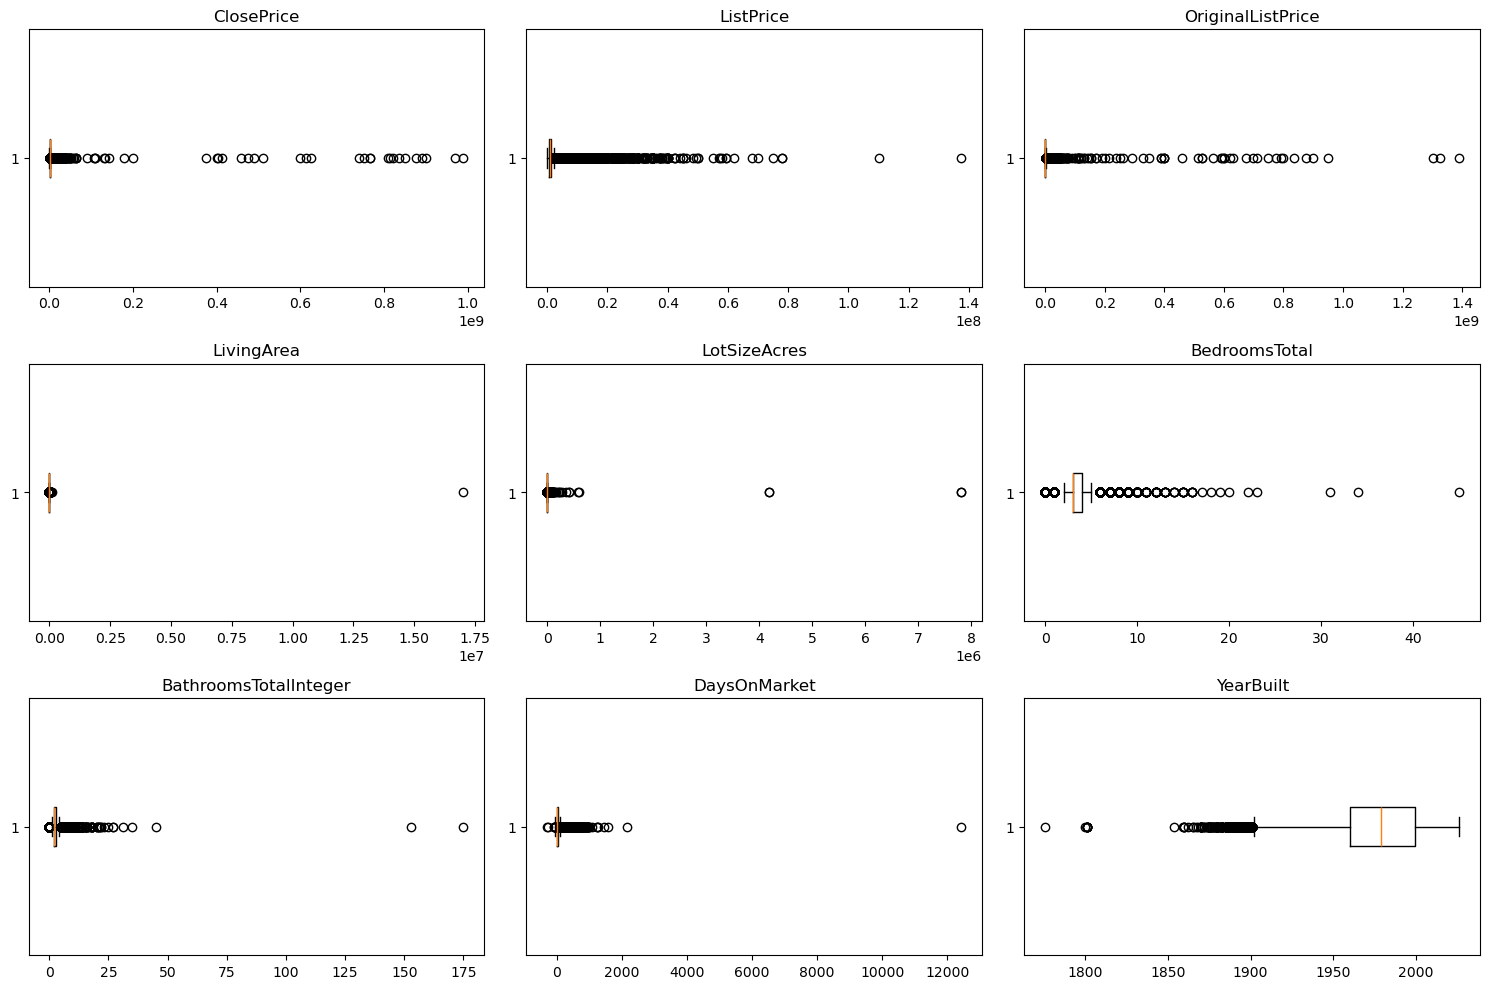

In [41]:
# Boxplots for numeric columns
n = len(numeric_cols)

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)  # adjust grid if needed
    plt.boxplot(sold_final[col].dropna(), vert=False)
    plt.title(col)

plt.tight_layout()
plt.show()

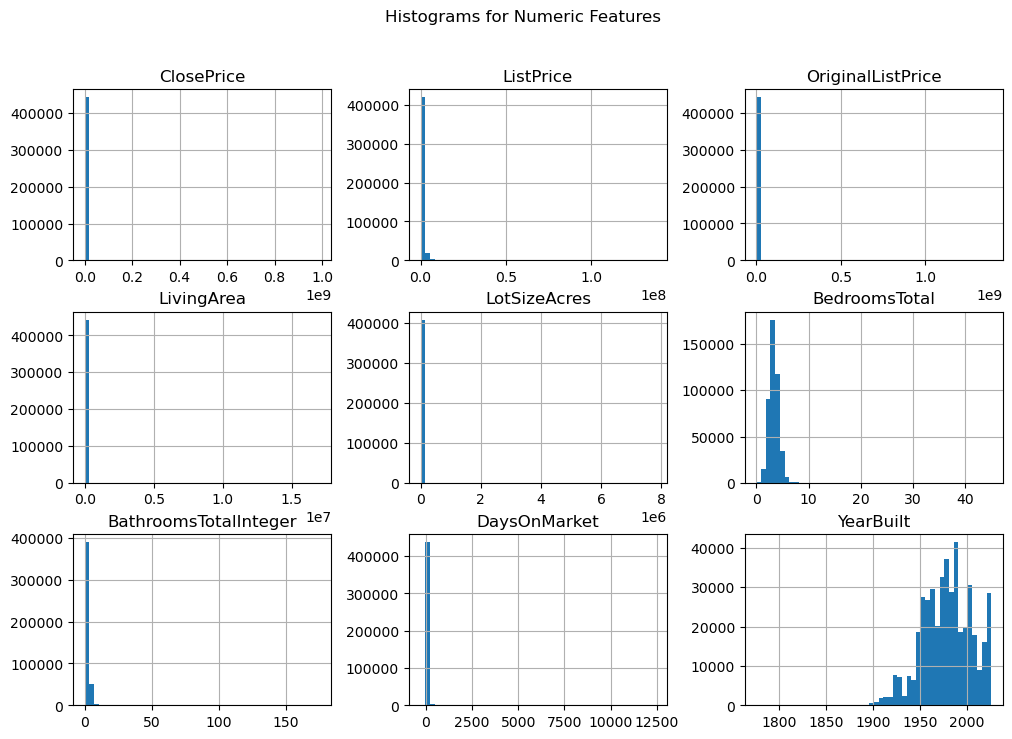

In [42]:
# Combined histograms in grid
sold_final[numeric_cols].hist(bins=50, figsize=(12, 8))
plt.suptitle("Histograms for Numeric Features")
plt.show()

### Identify extreme outliers (IQR Method)

In [43]:
outliers_dict = {}

for col in numeric_cols:
    if col in sold_final.columns:
        data = sold_final[col].dropna()

        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = data[(data < lower_bound) | (data > upper_bound)]

        outliers_dict[col] = len(outliers)

        print(f"{col}: {len(outliers)} outliers")

ClosePrice: 32609 outliers
ListPrice: 32913 outliers
OriginalListPrice: 34134 outliers
LivingArea: 19515 outliers
LotSizeAcres: 63988 outliers
BedroomsTotal: 24458 outliers
BathroomsTotalInteger: 20211 outliers
DaysOnMarket: 33293 outliers
YearBuilt: 1024 outliers


In [44]:
# Removed Unrealistic Outliers
# Define thresholds based on domain knowledge and summary statistics
thresholds = {
    "LivingArea": 10_000,      # Remove properties larger than 10,000 sqft
    "LotSizeAcres": 5,         # Remove properties with lot size larger than 5 acres
    "BedroomsTotal": 10,       # Remove properties with more than 10 bedrooms
    "BathroomsTotalInteger": 10, # Remove properties with more than 10 bathrooms
    "DaysOnMarket": 365,       # Remove properties that were on the market for more than 1 year
}

# Will remove ClosePrice outliers later, after we analyze the distribution more closely

### Key Takeaways
- Data is heavily right-skewed → median is a better measure than mean
- ClosePrice: Influenced by high-value outliers (luxury homes) → inflates mean
- LivingArea: Contains unrealistic max values → possible data quality issues
- LotSize: Extreme outlier skewing distribution → may need removal or validation
- DaysOnMarket: Includes negative and unusually high values → likely data errors

Overall, these patterns are expected in real estate data, but outliers and invalid values should be handled carefully before analysis.

### Suggested Intern Questions

In [45]:
# Q1. What is the Residential vs. other property type share?
property_summary = (
    listing_final['PropertyType']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
print(property_summary)

PropertyType
Residential   100.00
Name: proportion, dtype: float64


In [46]:
# sanity check to make sure all are residential
listing_final["PropertyType"].value_counts()

PropertyType
Residential    539213
Name: count, dtype: int64

In [47]:
# Q2. What are the median and average close prices?
median_price = round(sold_final['ClosePrice'].median(), 2)
mean_price = round(sold_final['ClosePrice'].mean(), 2)

print("Median Close Price:", median_price)
print("Average Close Price:", mean_price)

Median Close Price: 820000.0
Average Close Price: 1175902.21


- Average is much higher than median, indicating a right-skewed distribution with some high-end outliers
- The large gap between mean and median suggests the presence of high-end properties, 
- Reinforcing the need for outlier analysis or segmentation when modeling price trends.

In [48]:
# IQR method for outlier detection on ClosePrice
Q1 = sold_final["ClosePrice"].quantile(0.25)
Q3 = sold_final["ClosePrice"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Identify outliers
outliers = sold_final[
    (sold_final["ClosePrice"] < lower_bound) |
    (sold_final["ClosePrice"] > upper_bound)
]

print("Number of outliers:", outliers.shape[0])

# Outliers removed
sold_finalQ2 = sold_final[
    (sold_final["ClosePrice"] >= lower_bound) &
    (sold_final["ClosePrice"] <= upper_bound)
].copy()

Lower Bound: -512500.0
Upper Bound: 2387500.0
Number of outliers: 32609


- Anything over 2387500.0 are outliers, best to remove them
- 32609 homes are considered outliers which is ~7.37% of the dataset
- Not random and definitely due to luxury homes
- Extreme outliers were removed

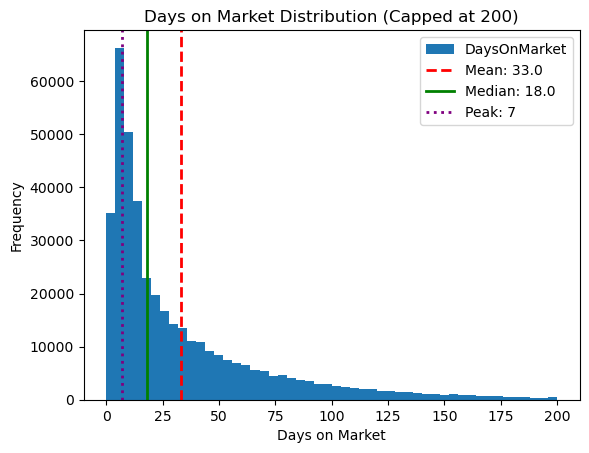

In [49]:
# Q3. Histogram of Days on Market with mean, median, and peak labels
sold_finalQ3 = sold_finalQ2[
    (sold_finalQ2["DaysOnMarket"] >= 0) &
    (sold_finalQ2["DaysOnMarket"] <= 200)
]

mean = sold_finalQ3["DaysOnMarket"].mean()
median = sold_finalQ3["DaysOnMarket"].median()
peak = sold_finalQ3["DaysOnMarket"].mode()[0]

sold_finalQ3['DaysOnMarket'].plot(kind='hist', bins=50)

plt.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {round(mean,1)}')
plt.axvline(median, color='green', linestyle='-', linewidth=2, label=f'Median: {median}')
plt.axvline(peak, color='purple', linestyle=':', linewidth=2, label=f'Peak: {peak}')


plt.title("Days on Market Distribution (Capped at 200)")
plt.xlabel("Days on Market")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [50]:
sold_finalQ3['DaysOnMarket'].describe()

count   403846.00
mean        33.03
std         37.29
min          0.00
25%          7.00
50%         18.00
75%         46.00
max        200.00
Name: DaysOnMarket, dtype: float64

The distribution of Days on Market is right-skewed, with most properties selling within a relatively short time frame. The median is lower than the mean, indicating the presence of outliers where some properties remain on the market significantly longer.
- Most homes sell quickly
- A few take much longer thus a skew
- The market is not evenly distributed

In [51]:
# Q3. What percentage of homes sold above vs. below list price?

sold_finalQ3['Above_List'] = sold_finalQ3['ClosePrice'] > sold_finalQ3['ListPrice']

# calculate the percentage of homes sold above vs. below list price
price_comparison = sold_finalQ3['Above_List'].value_counts(normalize=True) * 100

print(price_comparison)

# ~41% of homes sold above list price, while ~58% sold at or below list price.

Above_List
False   58.36
True    41.64
Name: proportion, dtype: float64


- ~42% of homes sold above list price |||| ~58% sold at or below list price
- Most homes are selling at or below asking
- So sellers aren't always getting bidding wars
- Market is not extremely overheated

- 41% is still high: indicates a strong demand in certain segments and competitive pockets of market

In [52]:
# Q4. Are there any apparent date consistency issues (e.g., close date before listing date)?

# We can check for date consistency by comparing the 'CloseDate' and 'ListDate' columns. If there are any rows where 'CloseDate' is before 'ListDate', that would indicate a potential issue.
sold_finalQ3['CloseDate'] = pd.to_datetime(sold_finalQ3['CloseDate'], errors='coerce')
sold_finalQ3['ListingContractDate'] = pd.to_datetime(sold_finalQ3['ListingContractDate'], errors='coerce')

date_issues = sold_finalQ3[sold_finalQ3['CloseDate'] < sold_finalQ3['ListingContractDate']]

print("Number of inconsistent records:", len(date_issues))

Number of inconsistent records: 46


- 46 records that showed as sold before it was listed
- It is logically impossible and the inconsistency are small enough to say it is safe to remove them

In [53]:
# remove records with date inconsistencies (if any)
sold_finalQ4 = sold_finalQ3[sold_finalQ3["CloseDate"] >= sold_finalQ3["ListingContractDate"]].copy()

In [54]:
date_issues[['ListingContractDate', 'CloseDate']].head()

,ListingContractDate,CloseDate
28878,2024-10-02,2024-09-19
29179,2024-09-30,2024-09-05
30015,2024-09-28,2024-09-24
70629,2025-01-24,2025-01-23
71358,2025-01-13,2025-01-10


In [55]:
# percentage (GOOD)
date_issue_percentage = (len(date_issues) / len(sold_finalQ4)) * 100
print(f"Percentage of date consistency issues: {date_issue_percentage:.2f}%")

Percentage of date consistency issues: 0.01%


In [56]:
# Which counties have the highest median prices?

# group by county, calculate median close price, and sort in descending order
county_median = (
    sold_finalQ4.groupby('CountyOrParish')['ClosePrice']
    .median()
    .sort_values(ascending=False)
)

print(county_median.head(10))

CountyOrParish
Santa Clara     1375000.00
San Mateo       1370000.00
Marin           1157500.00
San Francisco   1150000.00
Santa Cruz      1130000.00
Alameda         1088000.00
Orange          1075000.00
Mono             900000.00
San Diego        860000.00
Los Angeles      855000.00
Name: ClosePrice, dtype: float64


In [57]:
# Table format for better readability
county_median_df = county_median.reset_index()
county_median_df.columns = ['County', 'Median Close Price']

print(county_median_df.head(10))

          County  Median Close Price
0    Santa Clara          1375000.00
1      San Mateo          1370000.00
2          Marin          1157500.00
3  San Francisco          1150000.00
4     Santa Cruz          1130000.00
5        Alameda          1088000.00
6         Orange          1075000.00
7           Mono           900000.00
8      San Diego           860000.00
9    Los Angeles           855000.00


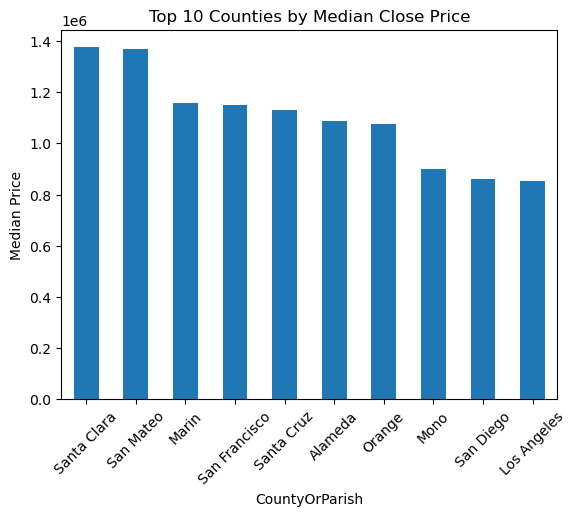

In [58]:
county_median.head(10).plot(kind='bar')
plt.title("Top 10 Counties by Median Close Price")
plt.ylabel("Median Price")
plt.xticks(rotation=45)
plt.show()

- Bay area dominates
    - high demand
    - tech industry
    - limited supply
- Coastal counties are expensive
- Key takeaway: location heavily impacts price

In [59]:
# Applying the thresholds to remove outliers from the sold_final dataset
sold_final2 = sold_finalQ4.copy()

for col, max_val in thresholds.items():
    sold_final2 = sold_final2[sold_final2[col] <= max_val]

In [60]:
# Sanity Check
print("Before:", sold_final.shape)
print("After:", sold_final2.shape)

Before: (442285, 39)
After: (359581, 40)


### Save the filtered dataset as a new CSV.

In [61]:
# Copying final cleaned datasets for export
sold_week2 = sold_finalQ4.copy()
listing_week2 = listing_final.copy()

# Save CSVs
sold_week2.to_csv("sold_week2.csv", index=False)
listing_week2.to_csv("listing_week2.csv", index=False)

### Final Key Takeaways
- Identified right-skewed distributions, especially in ClosePrice, due to high-value properties
- Compared mean vs. median to confirm the impact of luxury outliers
- Used the IQR method to detect and quantify outliers across numeric variables
- Removed unrealistic values using domain-based thresholds (e.g., extreme sizes, negative days)
- Retained meaningful outliers (e.g., luxury homes) to preserve market insights
- Created a cleaned dataset for more accurate and reliable analysis

### Tasks

In [62]:
# Inspect structure
sold_week2.columns

Index(['ClosePrice', 'ListPrice', 'OriginalListPrice', 'CloseDate',
       'PurchaseContractDate', 'ListingContractDate',
       'ContractStatusChangeDate', 'DaysOnMarket', 'LivingArea',
       'BuildingAreaTotal', 'BedroomsTotal', 'BathroomsTotalInteger',
       'LotSizeAcres', 'LotSizeSquareFeet', 'YearBuilt', 'Stories', 'Levels',
       'GarageSpaces', 'ParkingTotal', 'FireplacesTotal', 'FireplaceYN',
       'NewConstructionYN', 'AttachedGarageYN', 'CoveredSpaces',
       'MainLevelBedrooms', 'AboveGradeFinishedArea', 'BelowGradeFinishedArea',
       'City', 'CountyOrParish', 'PostalCode', 'StateOrProvince', 'Latitude',
       'Longitude', 'UnparsedAddress', 'SubdivisionName', 'MLSAreaMajor',
       'PropertyType', 'PropertySubType', 'MlsStatus', 'Above_List'],
      dtype='object')

In [63]:
sold_week2.head()

,ClosePrice,ListPrice,OriginalListPrice,CloseDate,PurchaseContractDate,ListingContractDate,ContractStatusChangeDate,DaysOnMarket,LivingArea,BuildingAreaTotal,...,StateOrProvince,Latitude,Longitude,UnparsedAddress,SubdivisionName,MLSAreaMajor,PropertyType,PropertySubType,MlsStatus,Above_List
2,250000.00,265000.00,265000.00,2024-04-02,2022-09-08,2021-09-15,2024-04-02,68,1723.00,NaN,...,CA,36.78,-119.77,3533 Virginia Lane N,NaN,NaN,Residential,SingleFamilyResidence,Closed,False
7,413700.00,414999.00,429000.00,2024-04-30,2021-09-05,2021-05-12,2024-04-30,64,2285.00,NaN,...,CA,33.61,-116.47,68252 Materhorn,",IDK","326 - Pinyon Pines, Garner Valley",Residential,SingleFamilyResidence,Closed,False
25,600000.00,600000.00,600000.00,2024-04-12,2024-04-03,2024-02-15,2024-04-12,0,1600.00,NaN,...,CA,32.74,-116.99,3457 Kenora Dr,Spring Valley,91977 - Spring Valley,Residential,SingleFamilyResidence,Closed,False
26,600000.00,575000.00,575000.00,2024-04-08,2024-04-07,2024-04-07,2024-04-08,0,1726.00,NaN,...,CA,37.71,-122.42,312 Argonaut Ave,NaN,NaN,Residential,NaN,Closed,True
27,1810000.00,1695000.00,899999.00,2024-04-10,2024-03-19,2024-03-10,2024-04-10,9,2001.00,NaN,...,CA,37.84,-122.13,846 Crossbrook Ct,NaN,NaN,Residential,SingleFamilyResidence,Closed,True


In [64]:
# Check property categories
sold_week2['PropertyType'].unique()


array(['Residential'], dtype=object)

In [65]:
# Filter residential
sold_week2 = sold_week2[sold_week2.PropertyType == 'Residential']

In [66]:
# Validate completeness
sold_week2.isnull().sum()

ClosePrice                       0
ListPrice                        0
OriginalListPrice              590
CloseDate                        0
PurchaseContractDate           163
ListingContractDate              0
ContractStatusChangeDate      1147
DaysOnMarket                     0
LivingArea                     123
BuildingAreaTotal           379621
BedroomsTotal                   10
BathroomsTotalInteger           73
LotSizeAcres                 33911
LotSizeSquareFeet            33501
YearBuilt                      221
Stories                      56724
Levels                       35153
GarageSpaces                 15129
ParkingTotal                   826
FireplacesTotal             403799
FireplaceYN                    262
NewConstructionYN            30233
AttachedGarageYN             61146
CoveredSpaces               403799
MainLevelBedrooms           162690
AboveGradeFinishedArea      403799
BelowGradeFinishedArea      401527
City                           310
CountyOrParish      

## Week 3 - Mortgage Rate Enrichment
- Enrich both the combined sold and listings datasets by merging in the national 30-year fixed mortgage rate from the St. Louis Federal Reserve (FRED).

In [67]:
# Step 1 – Fetch mortgage data
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
mortgage = pd.read_csv(url, parse_dates=['observation_date'])
mortgage.columns = ['date', 'rate_30yr_fixed']

# Step 2 – Convert to monthly average
mortgage['year_month'] = mortgage['date'].dt.to_period('M')

mortgage_monthly = (
    mortgage.groupby('year_month')['rate_30yr_fixed']
    .mean()
    .reset_index()
)

# Step 3 – Create matching key in your datasets

# SOLD dataset
sold_week2['year_month'] = pd.to_datetime(
    sold_week2['CloseDate'], errors='coerce'
).dt.to_period('M')

# LISTING dataset
listing_week2['year_month'] = pd.to_datetime(
    listing_week2['ListingContractDate'], errors='coerce'
).dt.to_period('M')

# Step 4 – Merge
sold_with_rates = sold_week2.merge(
    mortgage_monthly, on='year_month', how='left'
)

listing_with_rates = listing_week2.merge(
    mortgage_monthly, on='year_month', how='left'
)

# Step 5 – Validate
print("Missing sold rates:", sold_with_rates['rate_30yr_fixed'].isnull().sum())
print("Missing listing rates:", listing_with_rates['rate_30yr_fixed'].isnull().sum())

# Preview
print(
    sold_with_rates[
        ['CloseDate', 'year_month', 'ClosePrice', 'rate_30yr_fixed']
    ].head()
)

Missing sold rates: 0
Missing listing rates: 0
   CloseDate year_month  ClosePrice  rate_30yr_fixed
0 2024-04-02    2024-04   250000.00             6.99
1 2024-04-30    2024-04   413700.00             6.99
2 2024-04-12    2024-04   600000.00             6.99
3 2024-04-08    2024-04   600000.00             6.99
4 2024-04-10    2024-04  1810000.00             6.99


In [68]:
# Save to CSV files

sold_with_rates.to_csv("sold_with_rates.csv", index=False)
listing_with_rates.to_csv("listing_with_rates.csv", index=False)

## Weeks 4–5 – Data Cleaning and Preparation
Raw MLS data contains formatting inconsistencies, missing values, and fields that need transformation before analysis. This phase prepares the dataset for reliable analytics.

Tasks
- Convert date fields to datetime format (CloseDate, PurchaseContractDate, ListingContractDate, ContractStatusChangeDate)
- Remove unnecessary or redundant columns (removed earlier)
- Handle missing values appropriately
- Ensure numeric fields are properly typed
- Remove or flag invalid numeric values: ClosePrice <= 0, LivingArea <= 0, DaysOnMarket < 0, negative Bedrooms or Bathrooms


### Convert to Datetime Format

In [69]:
sold_with_rates.columns

Index(['ClosePrice', 'ListPrice', 'OriginalListPrice', 'CloseDate',
       'PurchaseContractDate', 'ListingContractDate',
       'ContractStatusChangeDate', 'DaysOnMarket', 'LivingArea',
       'BuildingAreaTotal', 'BedroomsTotal', 'BathroomsTotalInteger',
       'LotSizeAcres', 'LotSizeSquareFeet', 'YearBuilt', 'Stories', 'Levels',
       'GarageSpaces', 'ParkingTotal', 'FireplacesTotal', 'FireplaceYN',
       'NewConstructionYN', 'AttachedGarageYN', 'CoveredSpaces',
       'MainLevelBedrooms', 'AboveGradeFinishedArea', 'BelowGradeFinishedArea',
       'City', 'CountyOrParish', 'PostalCode', 'StateOrProvince', 'Latitude',
       'Longitude', 'UnparsedAddress', 'SubdivisionName', 'MLSAreaMajor',
       'PropertyType', 'PropertySubType', 'MlsStatus', 'Above_List',
       'year_month', 'rate_30yr_fixed'],
      dtype='object')

In [70]:
listing_with_rates.columns

Index(['ListPrice', 'OriginalListPrice', 'DaysOnMarket', 'ListingContractDate',
       'ContractStatusChangeDate', 'LivingArea', 'BuildingAreaTotal',
       'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres',
       'LotSizeSquareFeet', 'YearBuilt', 'Stories', 'Levels', 'GarageSpaces',
       'ParkingTotal', 'FireplacesTotal', 'FireplaceYN', 'NewConstructionYN',
       'AttachedGarageYN', 'CoveredSpaces', 'MainLevelBedrooms', 'City',
       'CountyOrParish', 'PostalCode', 'StateOrProvince', 'Latitude',
       'Longitude', 'UnparsedAddress', 'SubdivisionName', 'MLSAreaMajor',
       'PropertyType', 'PropertySubType', 'MlsStatus', 'year_month',
       'rate_30yr_fixed'],
      dtype='object')

In [71]:
# Function to convert date columns with error handling
def convert_date_columns(df, date_cols):
    cols = [col for col in date_cols if col in df.columns]
    missing = [col for col in date_cols if col not in df.columns]
    
    if missing:
        print(f"Missing columns: {missing}")
    
    df[cols] = df[cols].apply(pd.to_datetime, errors='coerce')
    
    return df

In [72]:
# Define date columns for each dataset (Sold)
date_cols_sold = [
    "CloseDate",
    "PurchaseContractDate",
    "ListingContractDate",
    "ContractStatusChangeDate"
]

sold_with_rates = convert_date_columns(sold_with_rates, date_cols_sold)

In [73]:
# Define date columns for each dataset (Listing)
date_cols_listing = [
    "ListingContractDate",
    "ContractStatusChangeDate"
]

listing_with_rates = convert_date_columns(listing_with_rates, date_cols_listing)

In [74]:
# Verify date conversion
sold_with_rates[date_cols_sold].dtypes
#listing_with_rates[date_cols_listing].dtypes

CloseDate                   datetime64[ns]
PurchaseContractDate        datetime64[ns]
ListingContractDate         datetime64[ns]
ContractStatusChangeDate    datetime64[ns]
dtype: object

### Remove unnecessary or redundant columns (removed earlier in Week 1)

In [75]:
# Sold
sold_missing = pd.DataFrame({
    "Missing Count": sold_with_rates.isna().sum()
})

sold_missing["Missing %"] = (
    sold_missing["Missing Count"] / len(sold_with_rates)
).round(2)

# Listing
listing_missing = pd.DataFrame({
    "Missing Count": listing_with_rates.isna().sum()
})

listing_missing["Missing %"] = (
    listing_missing["Missing Count"] / len(listing_with_rates)
).round(2)

### Handle missing values appropriately

In [76]:
from IPython.display import display, HTML

html = f"""
<div style="display: flex; gap: 40px;">
    <div>
        <h4>Sold Dataset</h4>
        {sold_missing[sold_missing["Missing Count"] > 0].to_html()}
    </div>
    <div>
        <h4>Listing Dataset</h4>
        {listing_missing[listing_missing["Missing Count"] > 0].to_html()}
    </div>
</div>
"""

display(HTML(html))

,Missing Count,Missing %
OriginalListPrice,590,0.00
PurchaseContractDate,163,0.00
ContractStatusChangeDate,1147,0.00
LivingArea,123,0.00
BuildingAreaTotal,379621,0.94
BedroomsTotal,10,0.00
BathroomsTotalInteger,73,0.00
LotSizeAcres,33911,0.08
LotSizeSquareFeet,33501,0.08
YearBuilt,221,0.00


In [105]:
# Rule-based column removal

datasets = {
    "sold": (sold_with_rates, sold_missing),
    "listing": (listing_with_rates, listing_missing)
}
cleaned_data = {}

for name, (df, missing_summary) in datasets.items():
    print(f"\nProcessing {name} dataset...")


    # 1. Drop columns with >90% missing
    high_missing_cols = missing_summary[
        missing_summary["Missing %"] > 0.90
].index.tolist()

    # 2. Manual drops
    manual_drop_cols = ["SubdivisionName"]

    # 3. Combine
    cols_to_drop = list(set(high_missing_cols + manual_drop_cols))

    # 4. Drop
    df_clean = df.drop(columns=cols_to_drop, errors="ignore")

    # 5. Store result
    cleaned_data[name] = df_clean

    # 6. Output summary
    print("Columns dropped:", cols_to_drop)
    print("Before:", df.shape)
    print("After:", df_clean.shape)

# Decided to keep MainLevelBedrooms despite missingness, as it could be a valuable feature for analysis and modeling.


Processing sold dataset...
Columns dropped: ['AboveGradeFinishedArea', 'FireplacesTotal', 'BuildingAreaTotal', 'CoveredSpaces', 'BelowGradeFinishedArea', 'SubdivisionName']
Before: (403799, 42)
After: (403799, 36)

Processing listing dataset...
Columns dropped: ['BuildingAreaTotal', 'SubdivisionName', 'CoveredSpaces', 'FireplacesTotal']
Before: (539213, 36)
After: (539213, 32)


In [108]:
# Track Data Loss (SOLD)
before = len(sold_clean)

sold_clean = sold_clean[
    (sold_clean["ClosePrice"] > 0) &
    (sold_clean["LivingArea"] > 0) &
    (sold_clean["DaysOnMarket"] >= 0) &
    (sold_clean["BedroomsTotal"] >= 0) & # Assuming 0 bedrooms is possible (e.g., studio apartments)
    (sold_clean["BathroomsTotalInteger"] >= 0)
]

after = len(sold_clean)
print(f"Sold rows removed: {before - after}")


### SAFER APPROACH JUST IN CASE ONE OF THESE COLUMNS DOESN'T EXIST
required_cols_sold = [
    "ClosePrice", "LivingArea", "DaysOnMarket",
    "BedroomsTotal", "BathroomsTotalInteger"
]

sold_clean = sold_clean.dropna(subset=required_cols_sold)

print(f"Percent removed: {(before - after)/before:.2%}")

Sold rows removed: 0
Percent removed: 0.00%


In [109]:
# Track Data Loss (Listing)
before = len(listing_clean)

listing_clean = listing_clean[
    (listing_clean["OriginalListPrice"] > 0) &
    (listing_clean["LivingArea"] > 0) &
    (listing_clean["DaysOnMarket"] >= 0) &
    (listing_clean["BedroomsTotal"] >= 0) &
    (listing_clean["BathroomsTotalInteger"] >= 0)
]

after = len(listing_clean)

required_cols_listing = [
    "OriginalListPrice", "LivingArea", "DaysOnMarket",
    "BedroomsTotal", "BathroomsTotalInteger"
]

listing_clean = listing_clean.dropna(subset=required_cols_listing)

print(f"Listing rows removed: {before - after}")
print(f"Percent removed: {(before - after) / before:.2%}")

Listing rows removed: 0
Percent removed: 0.00%


### Numeric Columns

In [110]:
# Define Numeric Columns
sold_numeric_cols = [
    "ClosePrice", "LivingArea", "DaysOnMarket",
    "BedroomsTotal", "BathroomsTotalInteger"
]

listing_numeric_cols = [
    "OriginalListPrice", "LivingArea", "DaysOnMarket",
    "BedroomsTotal", "BathroomsTotalInteger"
]

In [111]:
# Converts numeric columns, handles missing values, and applies validation rules to ensure data quality
def clean_numeric(df, numeric_cols, rules, name="dataset"):
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    before = len(df)

    df = df.dropna(subset=rules.keys())

    for col, condition in rules.items():
        df = df[condition(df[col])]

    after = len(df)
    print(f"{name}: removed {before - after} rows")

    return df


In [113]:
# Call function (more of a validaion step to ensure numeric columns are clean and meet expected criteria)
sold_rules = {
    "ClosePrice": lambda x: x > 0,
    "LivingArea": lambda x: x > 0,
    "DaysOnMarket": lambda x: x >= 0,
    "BedroomsTotal": lambda x: x >= 0,
    "BathroomsTotalInteger": lambda x: x >= 0  # MAYBE NEVER?
}

listing_rules = {
    "OriginalListPrice": lambda x: x > 0,
    "LivingArea": lambda x: x > 0,
    "DaysOnMarket": lambda x: x >= 0,
    "BedroomsTotal": lambda x: x >= 0,
    "BathroomsTotalInteger": lambda x: x >= 0
}

sold_clean = clean_numeric(sold_clean, sold_numeric_cols, sold_rules, "sold")
listing_clean = clean_numeric(listing_clean, listing_numeric_cols, listing_rules, "listing")

sold: removed 0 rows
listing: removed 0 rows


### Date Consistency Checks (Flags)

In [ ]:
# Validate date consistency by flagging missing critical dates and invalid event timelines
def add_date_flags(df):
    
    # Missing critical dates
    date_cols = ["ListingContractDate", "PurchaseContractDate", "CloseDate"]
    existing_cols = [col for col in date_cols if col in df.columns]
    
    if existing_cols:
        df["missing_critical_dates_flag"] = df[existing_cols].isna().any(axis=1)

    # Listing after close
    if "ListingContractDate" in df.columns and "CloseDate" in df.columns:
        df["listing_after_close_flag"] = (
            df["ListingContractDate"].notna() &
            df["CloseDate"].notna() &mv ~/Desktop/IDX_Week4-5.ipynb ~/Desktop/crmls/mls-data-analysis/notebooks/
            (df["ListingContractDate"] > df["CloseDate"])
        )

    # Purchase after close
    if "PurchaseContractDate" in df.columns and "CloseDate" in df.columns:
        df["purchase_after_close_flag"] = (
            df["PurchaseContractDate"].notna() &
            df["CloseDate"].notna() &
            (df["PurchaseContractDate"] > df["CloseDate"])
        )

    # Negative timeline
    if "ListingContractDate" in df.columns and "PurchaseContractDate" in df.columns:
        df["negative_timeline_flag"] = (
            df["ListingContractDate"].notna() &
            df["PurchaseContractDate"].notna() &
            (df["ListingContractDate"] > df["PurchaseContractDate"])
        )

    return df

In [115]:
sold_clean = add_date_flags(sold_clean)
listing_clean = add_date_flags(listing_clean)

In [116]:
# Sanity Check
sold_clean.filter(like="flag").sum()

missing_critical_dates_flag    12310
listing_after_close_flag         109
purchase_after_close_flag        403
negative_timeline_flag           380
invalid_price_flag                 0
invalid_area_flag                  0
invalid_dom_flag                   0
missing_coord_flag             18147
zero_coord_flag                   37
positive_longitude_flag           47
out_of_bounds_flag               157
any_coord_issue_flag           18304
any_issue_flag                 18989
dtype: int64

In [117]:
listing_clean.filter(like="flag").sum()

missing_critical_dates_flag    494501
listing_after_close_flag          126
purchase_after_close_flag         110
negative_timeline_flag            365
invalid_price_flag                  0
invalid_area_flag                   0
invalid_dom_flag                    0
missing_coord_flag              97115
zero_coord_flag                    76
positive_longitude_flag           102
out_of_bounds_flag                354
any_coord_issue_flag            97469
any_issue_flag                  97866
dtype: int64

### Numeric Consistency Checks

In [118]:
# Identify missing and invalid numeric values
# Sold
sold_clean["invalid_price_flag"] = (
    sold_clean["ClosePrice"].isna() | (sold_clean["ClosePrice"] <= 0)
)
sold_clean["invalid_area_flag"] = (
    sold_clean["LivingArea"].isna() | (sold_clean["LivingArea"] <= 0)
)
sold_clean["invalid_dom_flag"] = (
    sold_clean["DaysOnMarket"].isna() | (sold_clean["DaysOnMarket"] < 0)
)

# Listing
listing_clean["invalid_price_flag"] = (
    listing_clean["OriginalListPrice"].isna() | (listing_clean["OriginalListPrice"] <= 0)
)

listing_clean["invalid_area_flag"] = (
    listing_clean["LivingArea"].isna() | (listing_clean["LivingArea"] <= 0)
)

listing_clean["invalid_dom_flag"] = (
    listing_clean["DaysOnMarket"].isna() | (listing_clean["DaysOnMarket"] < 0)
)

### Geographic Data Checks

In [119]:
# Create flags to identify missing, invalid, and out-of-range geographic coordinates
def add_coordinate_flags(df, state_name="California"):
    df["missing_coord_flag"] = (
        df["Latitude"].isna() | df["Longitude"].isna()
    )

    df["zero_coord_flag"] = (
        (df["Latitude"] == 0) | (df["Longitude"] == 0)
    )

    df["positive_longitude_flag"] = (
        df["Longitude"] > 0
    )

    df["out_of_bounds_flag"] = (
        (df["Latitude"] < 32) | (df["Latitude"] > 42) |
        (df["Longitude"] < -125) | (df["Longitude"] > -114)
    )

    coord_flag_cols = [
        "missing_coord_flag",
        "zero_coord_flag",
        "positive_longitude_flag",
        "out_of_bounds_flag"
    ]

    df["any_coord_issue_flag"] = df[coord_flag_cols].any(axis=1)

    print(f"{state_name} coordinate issue counts:")
    print(df[coord_flag_cols].sum())

    return df

In [120]:
# Call the function for both datasets
sold_clean = add_coordinate_flags(sold_clean)
print("------------------------")
listing_clean = add_coordinate_flags(listing_clean)

California coordinate issue counts:
missing_coord_flag         18147
zero_coord_flag               37
positive_longitude_flag       47
out_of_bounds_flag           157
dtype: int64
------------------------
California coordinate issue counts:
missing_coord_flag         97115
zero_coord_flag               76
positive_longitude_flag      102
out_of_bounds_flag           354
dtype: int64


### Geographic Data Quality Summary
- A significant number of records have missing coordinates, which limits mapping and spatial analysis
- A small number of records contain (0,0) coordinates, likely placeholder or default values
- Some records show positive longitude values, which are invalid for California (should be negative)
- A subset of records fall outside expected California geographic bounds, indicating potential data entry or geocoding errors

Overall, most data is usable, but these flagged records may need to be removed or handled depending on analysis goals.

### Quick validation summary

In [121]:
# Define flags
date_flags = [
    "listing_after_close_flag",
    "purchase_after_close_flag",
    "negative_timeline_flag"
]

geo_flags = [
    "missing_coord_flag",
    "zero_coord_flag",
    "positive_longitude_flag",
    "out_of_bounds_flag"
]

numeric_flags = [
    "invalid_price_flag",
    "invalid_area_flag",
    "invalid_dom_flag"
]

all_flags = date_flags + geo_flags + numeric_flags

In [122]:
# Include percentages in the summary for better context on the prevalence of each issue
def summarize_flags(df, name):
    print(f"\n{name} Dataset Validation Summary")
    print("-" * 50)
    
    total = len(df)
    
    for col in all_flags:
        if col in df.columns:
            count = df[col].sum()
            pct = (count / total * 100) if total > 0 else 0
            print(f"{col}: {count} ({pct:.2f}%) flagged")

In [123]:
summarize_flags(sold_clean, "Sold")
summarize_flags(listing_clean, "Listing")


Sold Dataset Validation Summary
--------------------------------------------------
listing_after_close_flag: 109 (0.02%) flagged
purchase_after_close_flag: 403 (0.07%) flagged
negative_timeline_flag: 380 (0.06%) flagged
missing_coord_flag: 18147 (2.98%) flagged
zero_coord_flag: 37 (0.01%) flagged
positive_longitude_flag: 47 (0.01%) flagged
out_of_bounds_flag: 157 (0.03%) flagged
invalid_price_flag: 0 (0.00%) flagged
invalid_area_flag: 0 (0.00%) flagged
invalid_dom_flag: 0 (0.00%) flagged

Listing Dataset Validation Summary
--------------------------------------------------
listing_after_close_flag: 126 (0.02%) flagged
purchase_after_close_flag: 110 (0.01%) flagged
negative_timeline_flag: 365 (0.05%) flagged
missing_coord_flag: 97115 (13.11%) flagged
zero_coord_flag: 76 (0.01%) flagged
positive_longitude_flag: 102 (0.01%) flagged
out_of_bounds_flag: 354 (0.05%) flagged
invalid_price_flag: 0 (0.00%) flagged
invalid_area_flag: 0 (0.00%) flagged
invalid_dom_flag: 0 (0.00%) flagged


In [124]:
# Create a row-level data quality score by aggregating validation flags
def add_quality_metrics(df):
    flag_cols = [col for col in all_flags if col in df.columns]

    # Total issues per row
    df["total_issue_count"] = df[flag_cols].sum(axis=1)

    # Any issue flag
    df["any_issue_flag"] = df["total_issue_count"] > 0

    # Data quality score (1 = perfect, 0 = worst)
    if len(flag_cols) > 0:
        df["data_quality_score"] = 1 - (df["total_issue_count"] / len(flag_cols))
    else:
        df["data_quality_score"] = 1

    return df

In [125]:
# Add quality metrics to both datasets
sold_clean = add_quality_metrics(sold_clean)
listing_clean = add_quality_metrics(listing_clean)

In [126]:
# Add a quick summary function to report the number and percentage of rows with any issues, providing a clear overview of overall data quality
def summarize_group(df, flags, label):
    total = len(df)
    count = df[flags].any(axis=1).sum()
    pct = count / total * 100 if total > 0 else 0
    print(f"{label}: {count} rows ({pct:.2f}%) have issues")

In [127]:
summarize_group(sold_clean, date_flags, "Date Issues")
summarize_group(sold_clean, geo_flags, "Geo Issues")
summarize_group(sold_clean, numeric_flags, "Numeric Issues")

Date Issues: 789 rows (0.13%) have issues
Geo Issues: 18304 rows (3.00%) have issues
Numeric Issues: 0 rows (0.00%) have issues


In [128]:
summarize_group(listing_clean, date_flags, "Date Issues")
summarize_group(listing_clean, geo_flags, "Geo Issues")
summarize_group(listing_clean, numeric_flags, "Numeric Issues")

Date Issues: 483 rows (0.07%) have issues
Geo Issues: 97469 rows (13.15%) have issues
Numeric Issues: 0 rows (0.00%) have issues


In [129]:
print(sold_clean.dtypes)
print("------------------------")
print(listing_clean.dtypes)

AboveGradeFinishedArea     float64
AssociationFee             float64
AssociationFeeFrequency     object
AttachedGarageYN            object
BasementYN                  object
                            ...   
out_of_bounds_flag            bool
any_coord_issue_flag          bool
total_issue_count            int64
any_issue_flag                bool
data_quality_score         float64
Length: 99, dtype: object
------------------------
AboveGradeFinishedArea     float64
AssociationFee             float64
AssociationFeeFrequency     object
AttachedGarageYN            object
BathroomsTotalInteger      float64
                            ...   
out_of_bounds_flag            bool
any_coord_issue_flag          bool
total_issue_count            int64
any_issue_flag                bool
data_quality_score         float64
Length: 88, dtype: object


### Data Transformation Summary
- Converted date fields to datetime format to support timeline validation
- Removed redundant and high-missing columns to improve data usability
- Standardized numeric fields and ensured proper data types
- Filtered invalid records (e.g., non-positive price, area, and negative days on market)
- Created date consistency flags to identify timeline issues across listing, purchase, and close dates (where applicable)
- Applied geographic validation to flag missing, invalid, and out-of-range coordinates

Overall, these transformations improved data quality, reduced noise, and ensured both datasets are clean and analysis-ready.

### Saved CSV for Week 4-5

In [130]:
sold_clean.to_csv("sold_week4_5.csv", index=False)
listing_clean.to_csv("listing_week4_5.csv", index=False)